1. Постановка задачи

Проанализировать данные олимпийских атлетов, убрать "грязные данные", дубликаты, аномальные данные, посмотреть как разные характеристики влияют на олимпийских спортсменов и их результаты. 

2. Подключение библиотек

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

3. Загрузка данных

In [3]:
ch = pd.read_excel("3_OLYMPICS_athlete_events.xlsx")

In [4]:
ch.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


### Описание данных:

Признаки:
- ID - номер атлета
- Name - имя атлета
- Sex - пол
- Age - возраст
- Height - рост
- Weight-вес
- Team - команда
- NOC - Национальный олимпийский комитет
- year - год
- season - сезон/время года
- city - город
- sport - вид спорта
- event - событие
- medal - тип медали

In [5]:
ch.shape

(271116, 15)

In [6]:
ch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


можно увидеть пропущенные значения в полях Age, Height, Weight, Medal

In [7]:
ch.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'Year'}>, <Axes: >]], dtype=object)

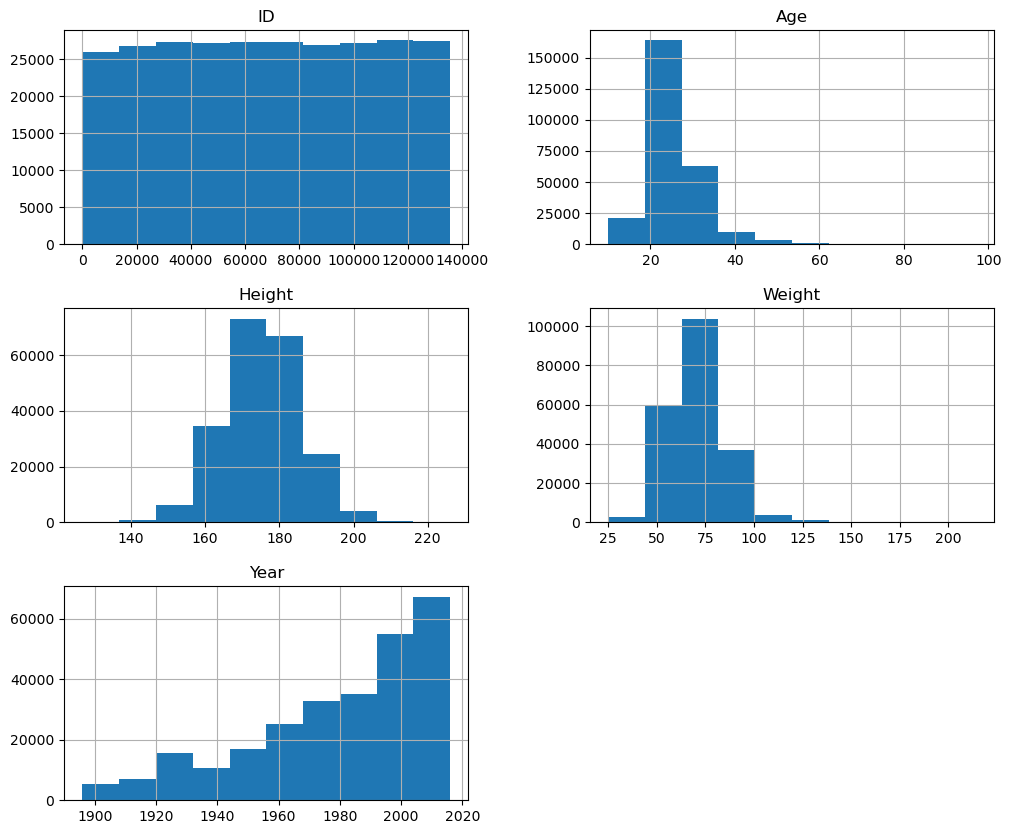

In [8]:
ch.hist(figsize=(12,10))

самый популярный возраст от 20 до 30, рост от 165 до 175, вес от 60 до 80. 

In [9]:
ch[ch["Height"]==127]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
29333,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Individual All-Around,NaN
29334,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Team All-Around,NaN
29335,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Floor Exercise,NaN
29336,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Horse Vault,NaN
29337,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Uneven Bars,NaN
29338,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Balance Beam,NaN
164821,82769,Lyton Levison Mphande,M,25.0,127.0,62.0,Malawi,MAW,1988 Summer,1988,Summer,Seoul,Boxing,Boxing Men's Light-Welterweight,NaN


In [10]:
ch[ch["Weight"]==25]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40849,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Individual All-Around,NaN
40850,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Team All-Around,NaN
40851,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Floor Exercise,NaN
40852,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Horse Vault,NaN
40853,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Uneven Bars,NaN
40854,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Balance Beam,NaN


In [11]:
ch[ch["Weight"]>200]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
23155,12177,"Ricardo Blas, Jr.",M,21.0,183.0,214.0,Guam,GUM,2008 Summer,2008,Summer,Beijing,Judo,Judo Men's Heavyweight,NaN
23156,12177,"Ricardo Blas, Jr.",M,25.0,183.0,214.0,Guam,GUM,2012 Summer,2012,Summer,London,Judo,Judo Men's Heavyweight,NaN


In [12]:
ch[ch["Age"]>80]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
9371,5146,George Denholm Armour,M,84.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
60861,31173,Thomas Cowperthwait Eakins,M,88.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
60862,31173,Thomas Cowperthwait Eakins,M,88.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
60863,31173,Thomas Cowperthwait Eakins,M,88.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
98118,49663,Winslow Homer,M,96.0,NaN,NaN,United States,USA,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
154855,77710,Robert Tait McKenzie,M,81.0,NaN,NaN,Canada,CAN,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Sculpturing, Unknown Event",NaN
236912,118789,Louis Tauzin,M,81.0,NaN,NaN,France,FRA,1924 Summer,1924,Summer,Paris,Art Competitions,Art Competitions Mixed Sculpturing,NaN
257054,128719,John Quincy Adams Ward,M,97.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN


In [13]:
ch.describe(include="O")

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,271116,271116,271116,271116,271116,271116,271116,271116,271116,39783
unique,134732,2,1184,230,51,2,42,66,765,3
top,Robert Tait McKenzie,M,United States,USA,2000 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,58,196594,17847,18853,13821,222552,22426,38624,5733,13372


стоит привести все значения в различных колонках к единому регистру, и придумать что-то с колонкой Games так как она аналогична Season+Year

4. Разведочный анализ данных(EDA)

4. Проверка на пропуски и дубликаты

In [14]:
ch.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

в поле медаль много пропущенных значений так как у некоторых нет медали, поменяю пропущенные значения на "No medal"

In [15]:
ch["Medal"] = ch["Medal"].fillna("No Medal")

In [16]:
ch.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal


Для пропущенных значений в колонке Age, Height, Weight медиана данной колонки и колонки спорт.

In [17]:
ch['Age'] = ch.groupby('Sport')['Age'].transform(
    lambda x: x.fillna(x.mean())
)
ch['Age'] = ch.groupby('Sport')['Height'].transform(
    lambda x: x.fillna(x.mean())
)
ch['Age'] = ch.groupby('Sport')['Weight'].transform(
    lambda x: x.fillna(x.mean())
)

Оставшиеся значения просто медианы этих колонок. 

In [21]:
ch['Height'] = ch['Height'].fillna(ch['Height'].median())
ch['Weight'] = ch['Weight'].fillna(ch['Weight'].median())
ch['Age'] = ch['Age'].fillna(ch['Age'].median())


Выполним проверку:

In [22]:
ch.isna().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64

Пропущенных значений больше нет.

6. Привожу к одному регистру строковые значения

снчала проверим уникальные на текущий момент

In [23]:
print(ch["Name"].nunique())
print(ch["Sex"].nunique())
print(ch["Season"].nunique())
print(ch["City"].nunique())
print(ch["Sport"].nunique())
print(ch["Event"].nunique())
print(ch["Medal"].nunique())

134732
2
2
42
66
765
4


In [24]:
ch['Name'] = ch['Name'].str.title()
ch['Sex'] = ch['Sex'].str.upper()
ch['Season'] = ch['Season'].str.title()
ch['City'] = ch['City'].str.title()
ch['Sport'] = ch['Sport'].str.title()
ch['Event'] = ch['Event'].str.title()
ch['Medal'] = ch['Medal'].str.title()

In [25]:
print(ch["Name"].nunique())
print(ch["Sex"].nunique())
print(ch["Season"].nunique())
print(ch["City"].nunique())
print(ch["Sport"].nunique())
print(ch["Event"].nunique())
print(ch["Medal"].nunique())

134731
2
2
42
66
765
4


из всех произведенных действий только одно имя привелось к нужному значению, но тем неменее можно быть увереным, что все поля заполнены в соответствующем регистре.

Произведу проверку самых очевидных столбцов на их содержимое:

In [26]:
ch["Sex"].unique()

array(['M', 'F'], dtype=object)

In [27]:
ch["Season"].unique()

array(['Summer', 'Winter'], dtype=object)

In [28]:
ch["City"].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Calgary',
       'Albertville', 'Lillehammer', 'Los Angeles', 'Salt Lake City',
       'Helsinki', 'Lake Placid', 'Sydney', 'Atlanta', 'Stockholm',
       'Sochi', 'Nagano', 'Torino', 'Beijing', 'Rio De Janeiro', 'Athina',
       'Squaw Valley', 'Innsbruck', 'Sarajevo', 'Mexico City', 'Munich',
       'Seoul', 'Berlin', 'Oslo', "Cortina D'Ampezzo", 'Melbourne',
       'Roma', 'Amsterdam', 'Montreal', 'Moskva', 'Tokyo', 'Vancouver',
       'Grenoble', 'Sapporo', 'Chamonix', 'St. Louis', 'Sankt Moritz',
       'Garmisch-Partenkirchen'], dtype=object)

In [29]:
ch["Medal"].unique()

array(['No Medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

просмотрев ключевые значения с определенными данными, можно понять что все значения теперь правильные, нет пропущенных и аномальных

In [30]:
ch.describe(include="O")

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,271116,271116,271116,271116,271116,271116,271116,271116,271116,271116
unique,134731,2,1184,230,51,2,42,66,765,4
top,Robert Tait Mckenzie,M,United States,USA,2000 Summer,Summer,London,Athletics,Football Men'S Football,No Medal
freq,58,196594,17847,18853,13821,222552,22426,38624,5733,231333


In [31]:
ch.shape

(271116, 15)

Так же собираюсь удалить стобец Games так как он соответствует столбцам Year+Season, но перед этим проверю, что действительно все строки в столбцах одинаковы:

In [32]:
ch[ch["Year"].astype(str) + " " + ch["Season"] != ch["Games"]]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal


как можно увидеть всего у нас 269177 строк и свопадающих колонок games в комбинации с year+season столько же, значит в этом столбце нет смысла и можно его удалить

In [33]:
ch.drop('Games', axis=1, inplace=True)

In [34]:
ch

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,80.000000,180.0,80.0,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men'S Basketball,No Medal
1,2,A Lamusi,M,60.000000,170.0,60.0,China,CHN,2012,Summer,London,Judo,Judo Men'S Extra-Lightweight,No Medal
2,3,Gunnar Nielsen Aaby,M,70.446834,175.0,70.0,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men'S Football,No Medal
3,4,Edgar Lindenau Aabye,M,95.615385,175.0,70.0,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men'S Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,82.000000,185.0,82.0,Netherlands,NED,1988,Winter,Calgary,Speed Skating,Speed Skating Women'S 500 Metres,No Medal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej Ya,M,89.000000,179.0,89.0,Poland-1,POL,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'S Doubles,No Medal
271112,135570,Piotr Ya,M,59.000000,176.0,59.0,Poland,POL,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men'S Large Hill, Individual",No Medal
271113,135570,Piotr Ya,M,59.000000,176.0,59.0,Poland,POL,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men'S Large Hill, Team",No Medal
271114,135571,Tomasz Ireneusz Ya,M,96.000000,185.0,96.0,Poland,POL,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men'S Four,No Medal


7. Анализ данных

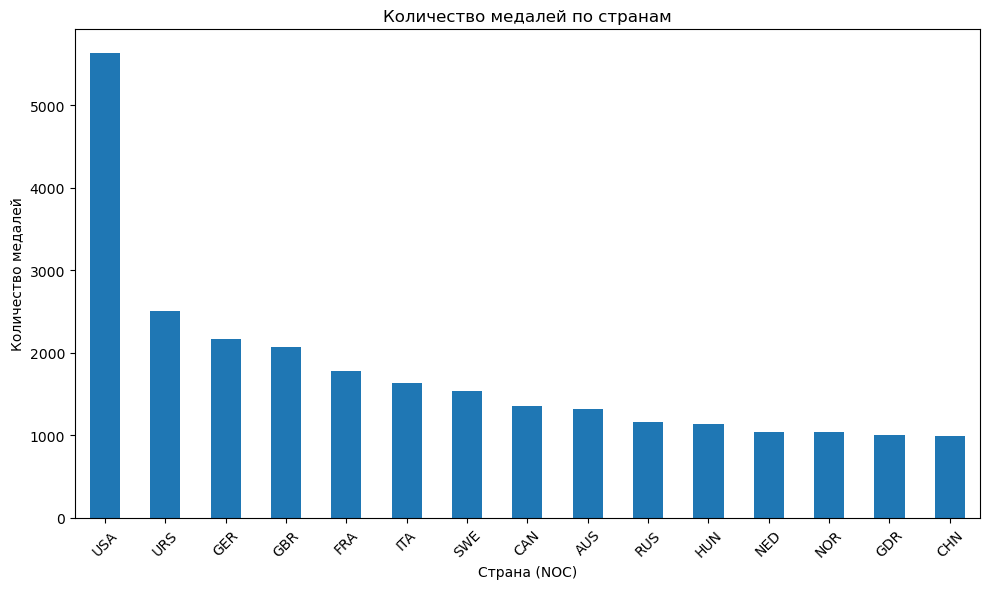

In [35]:
medals_df = ch[ch['Medal']!="No Medal"]
medals_by_country = medals_df.groupby('NOC').size().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
medals_by_country.plot(kind='bar')
plt.title('Количество медалей по странам')
plt.xlabel('Страна (NOC)')
plt.ylabel('Количество медалей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

самая популярная страна США, но Россия тооже входит в десятку лидеров.

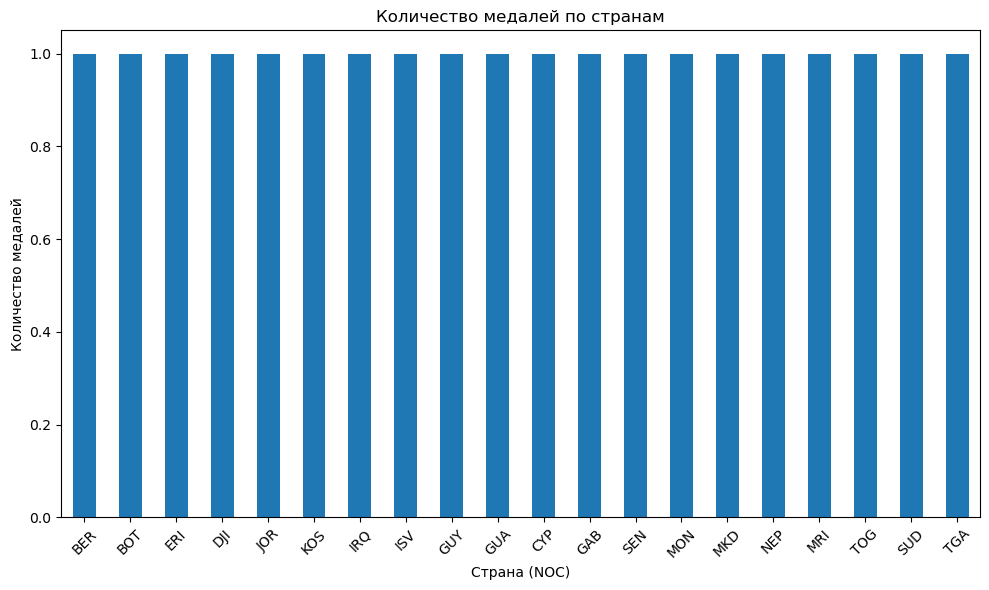

In [42]:
medals_df = ch[ch['Medal']!="No Medal"]
medals_by_country = medals_df.groupby('NOC').size().sort_values(ascending=False).tail(20)
plt.figure(figsize=(10, 6))
medals_by_country.plot(kind='bar')
plt.title('Количество медалей по странам')
plt.xlabel('Страна (NOC)')
plt.ylabel('Количество медалей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

а крайние 20 стран получили буквально по 1 медали

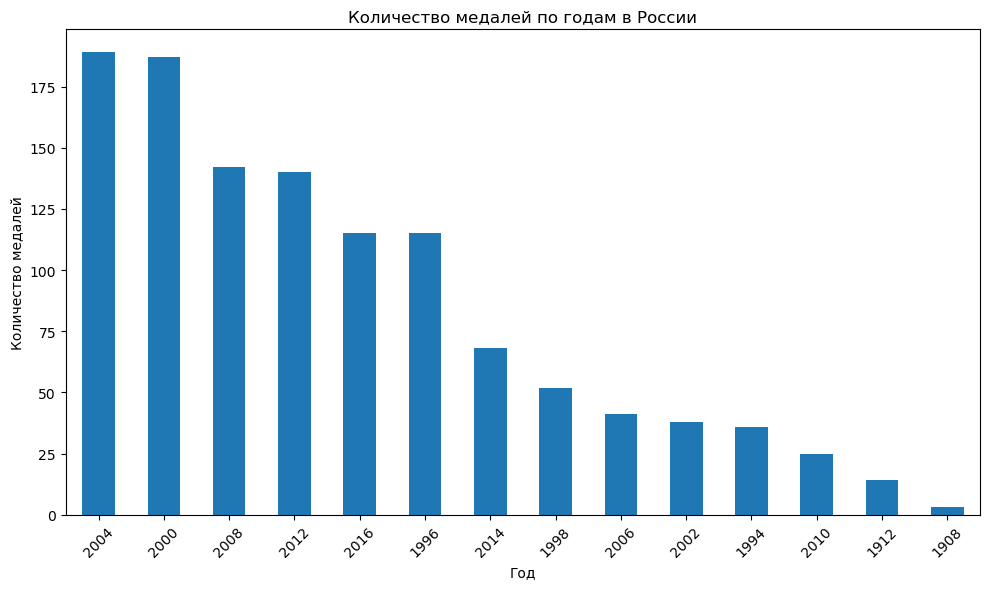

In [46]:
medals_df = ch[(ch['Medal']!="No Medal") & (ch["NOC"] == "RUS")]
medals_by_country = medals_df.groupby('Year').size().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
medals_by_country.plot(kind='bar')
plt.title('Количество медалей по годам в России')
plt.xlabel('Год')
plt.ylabel('Количество медалей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

количество медалей каждый год у россии увеличивается

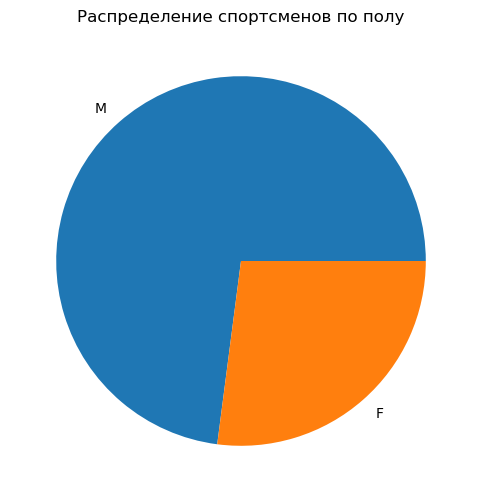

In [20]:
plt.figure(figsize=(10, 6))
gender_counts = ch['Sex'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index)
plt.title('Распределение спортсменов по полу')
plt.show()

Преимущественно атлеты - мужчины.

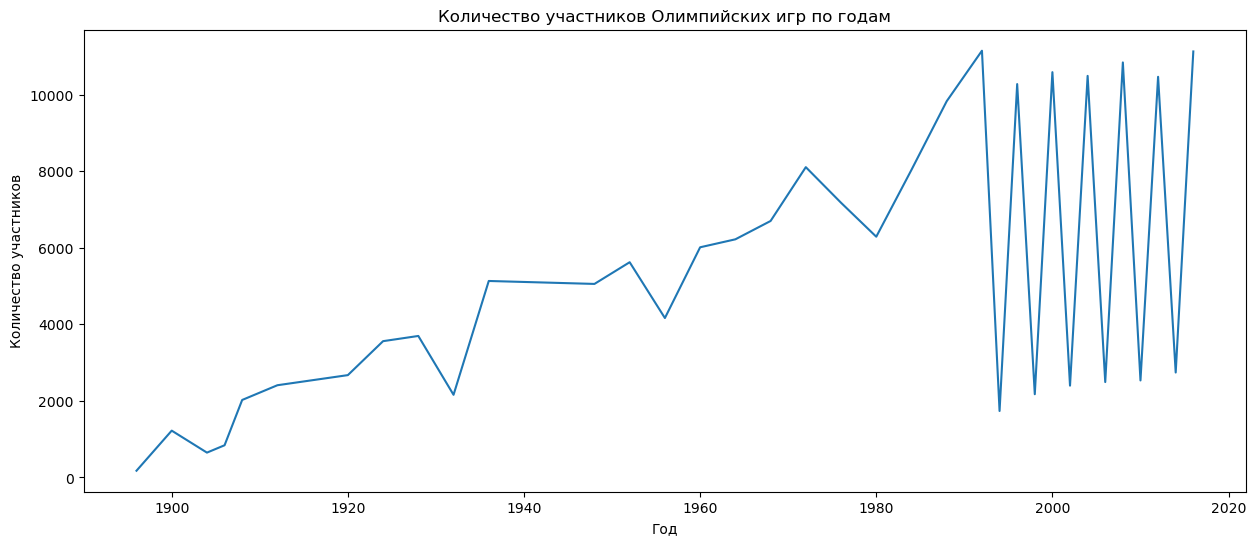

In [24]:
plt.figure(figsize=(15, 6))
chh = ch.groupby('Year')['ID'].nunique()
chh.plot(kind='line')
plt.title('Количество участников Олимпийских игр по годам')
plt.xlabel('Год')
plt.ylabel('Количество участников')
plt.show()

Количество спортсменов с самого начала увеличивалось и достигло своего пика впримерно в 1990 году, потом данное значение постоянно то увеличивалось, то уменьшалось.

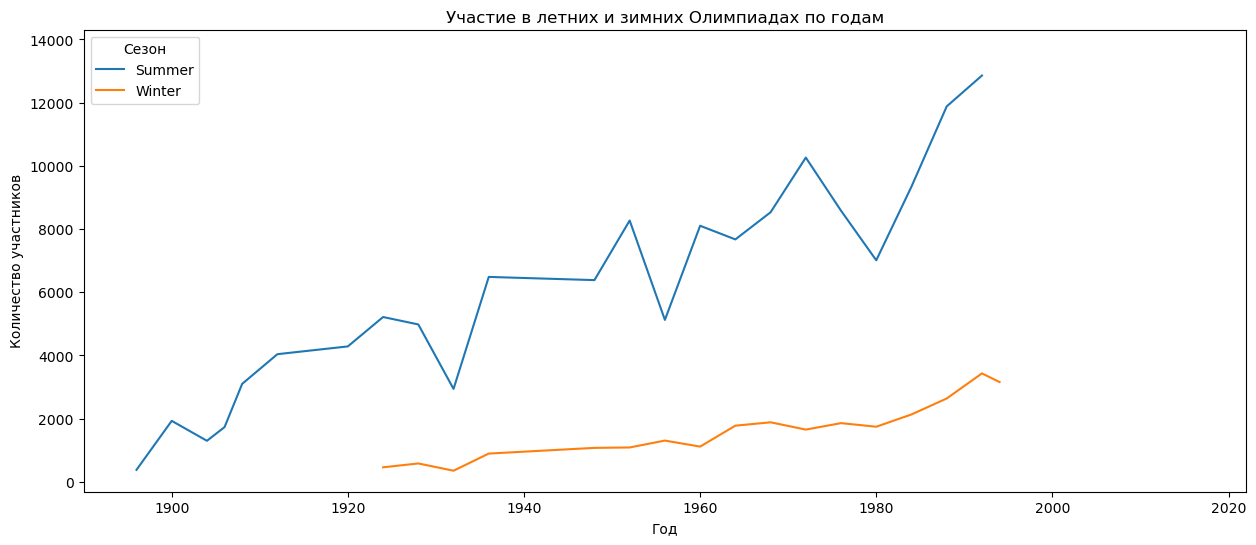

In [25]:
st = ch.groupby(['Year', 'Season']).size().unstack()
st.plot(kind='line', figsize=(15, 6))
plt.title('Участие в летних и зимних Олимпиадах по годам')
plt.xlabel('Год')
plt.ylabel('Количество участников')
plt.legend(title='Сезон')
plt.show()

Преимущественно и уже очень давно участвуют именно летом и их число увеличивается.

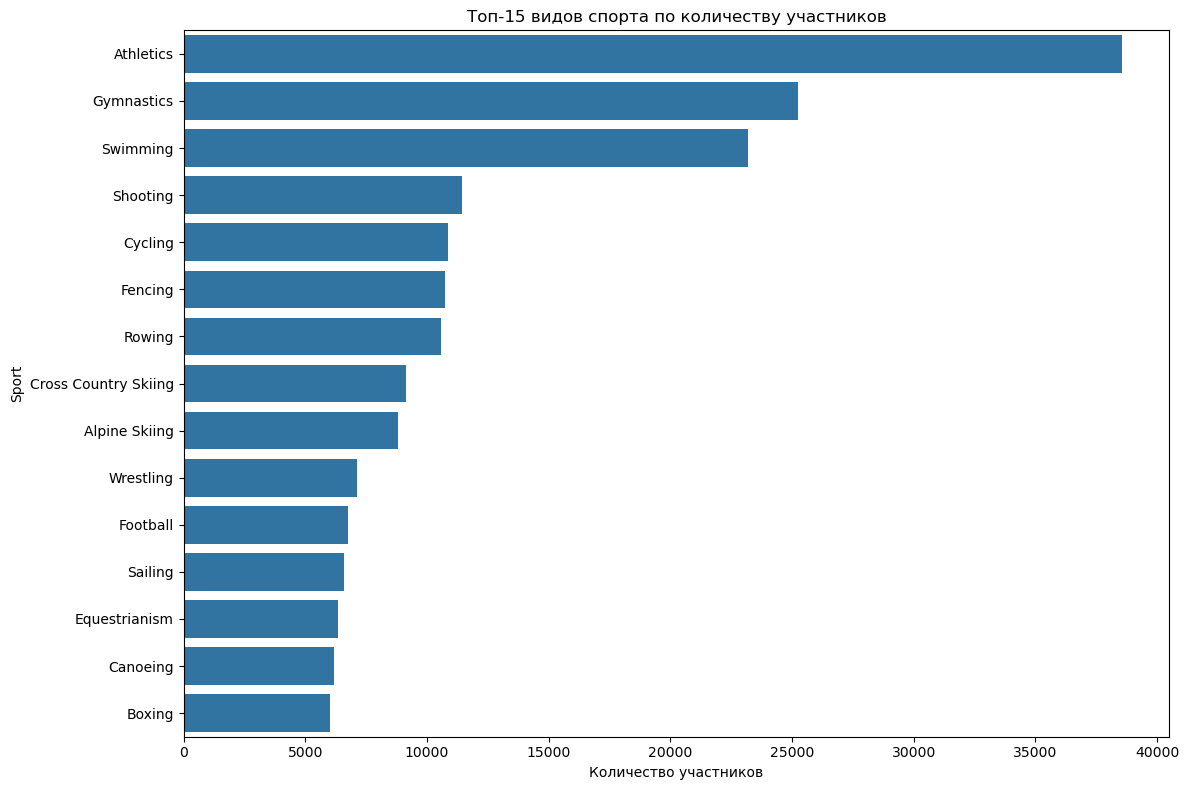

In [26]:
plt.figure(figsize=(12, 8))
top_sports = ch['Sport'].value_counts().head(15)
sns.barplot(x=top_sports.values, y=top_sports.index)
plt.title('Топ-15 видов спорта по количеству участников')
plt.xlabel('Количество участников')
plt.tight_layout()
plt.show()

Больше всего спортсменов в атлетике, гимнастике и плавании.

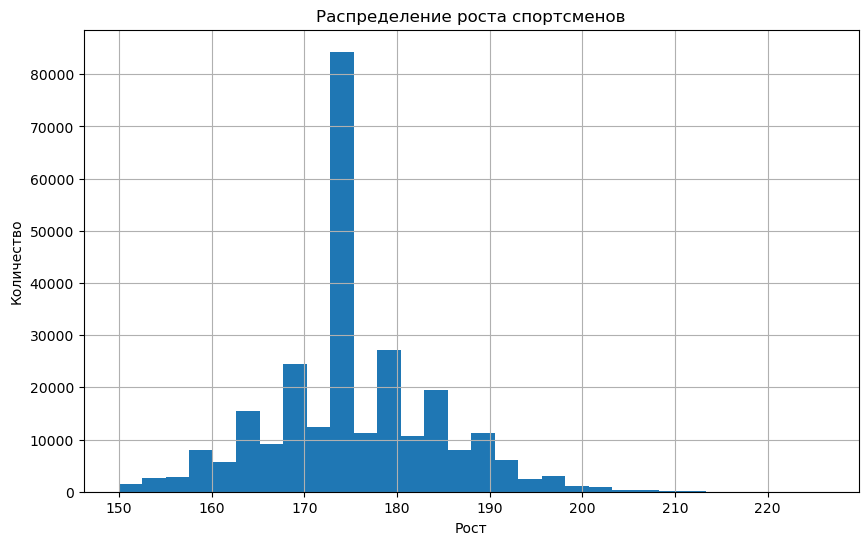

In [29]:
plt.figure(figsize=(10, 6))
ch['Height'].hist(bins=30)
plt.title('Распределение роста спортсменов')
plt.xlabel('Рост')
plt.ylabel('Количество')
plt.show()

Преимущественный рост у спортсменов от 170-180.

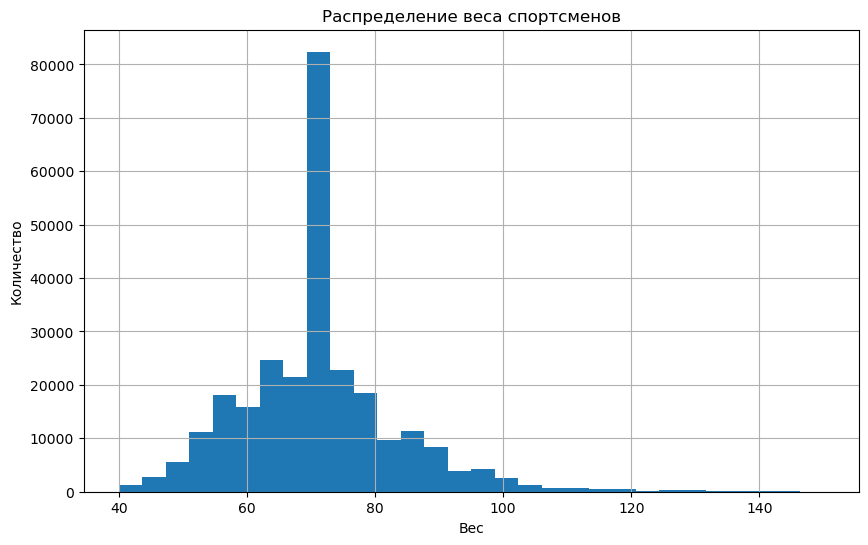

In [30]:
plt.figure(figsize=(10, 6))
ch['Weight'].hist(bins=30)
plt.title('Распределение веса спортсменов')
plt.xlabel('Вес')
plt.ylabel('Количество')
plt.show()

Преимущественно вес у спортсменов от 65 до 75.

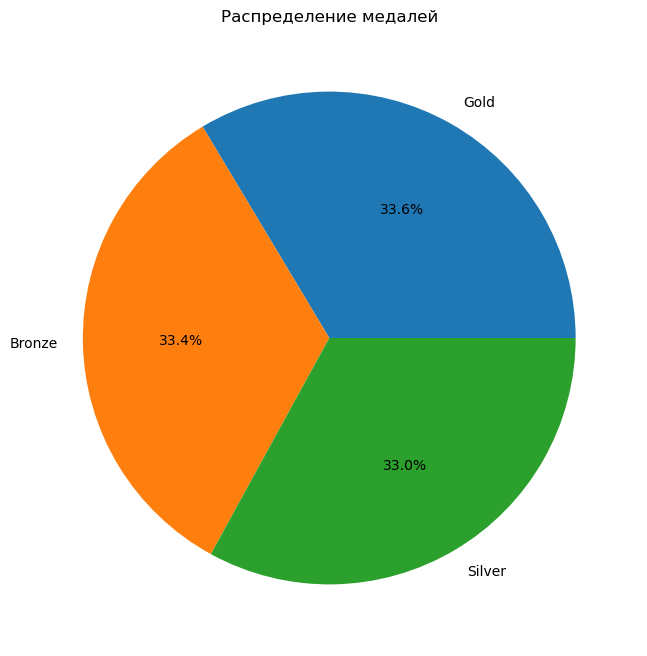

In [34]:
medal_counts = ch[ch['Medal'] != 'No Medal']['Medal'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(medal_counts.values, labels=medal_counts.index, autopct='%1.1f%%')
plt.title('Распределение медалей')
plt.show()

Медалей примерно одинаковое соотношение относительно всех спортсменов.

Равномерность распределения по всем числовым данным:

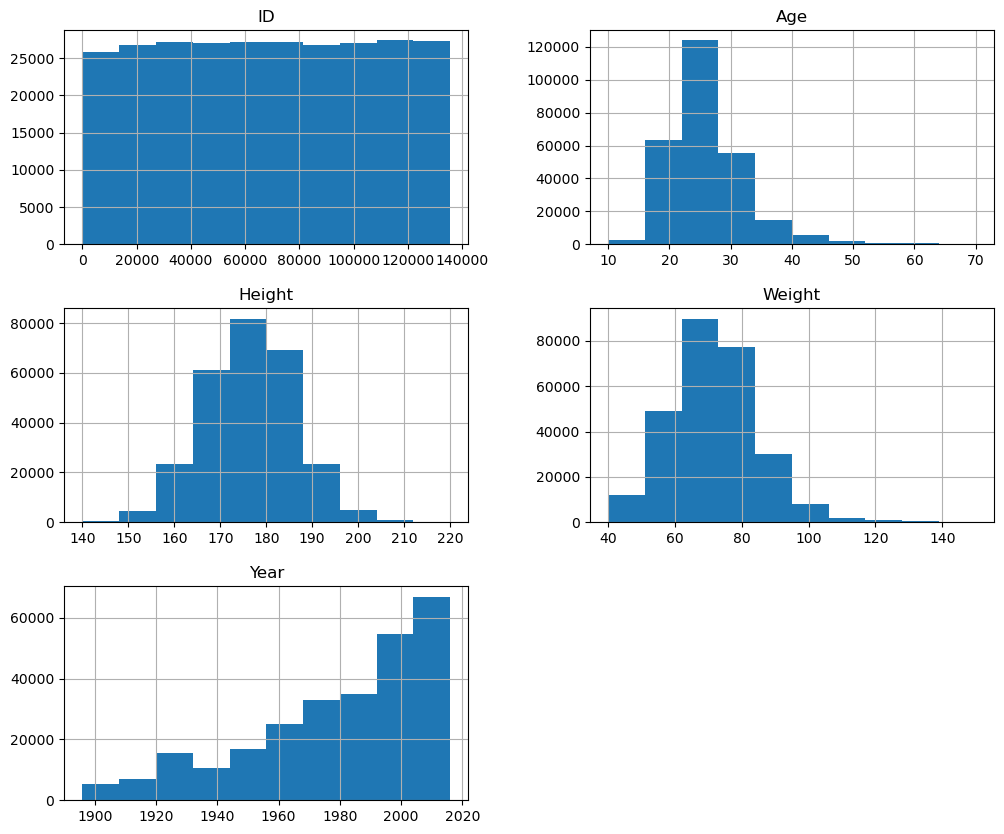

In [44]:
ch.hist(figsize=(12,10));

In [51]:
ch['Available'] = ch['Medal'].apply(lambda x: 0 if x == "No Medal" else 1)
ch

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Available
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men'S Basketball,No Medal,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012,Summer,London,Judo,Judo Men'S Extra-Lightweight,No Medal,0
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men'S Football,No Medal,0
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men'S Tug-Of-War,Gold,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988,Winter,Calgary,Speed Skating,Speed Skating Women'S 500 Metres,No Medal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej Ya,M,29.0,179.0,89.0,Poland-1,POL,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'S Doubles,No Medal,0
271112,135570,Piotr Ya,M,27.0,176.0,59.0,Poland,POL,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men'S Large Hill, Individual",No Medal,0
271113,135570,Piotr Ya,M,27.0,176.0,59.0,Poland,POL,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men'S Large Hill, Team",No Medal,0
271114,135571,Tomasz Ireneusz Ya,M,30.0,185.0,96.0,Poland,POL,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men'S Four,No Medal,0


Теперь посмотрим связи между данными:

In [52]:
ch_corr=ch[[ 'Age', 'Height', 'Weight', 'Available']].corr()
ch_corr

,Age,Height,Weight,Available
Age,1.000000,0.105174,0.158762,0.025542
Height,0.105174,1.000000,0.786674,0.077369
Weight,0.158762,0.786674,1.000000,0.077385
Available,0.025542,0.077369,0.077385,1.000000


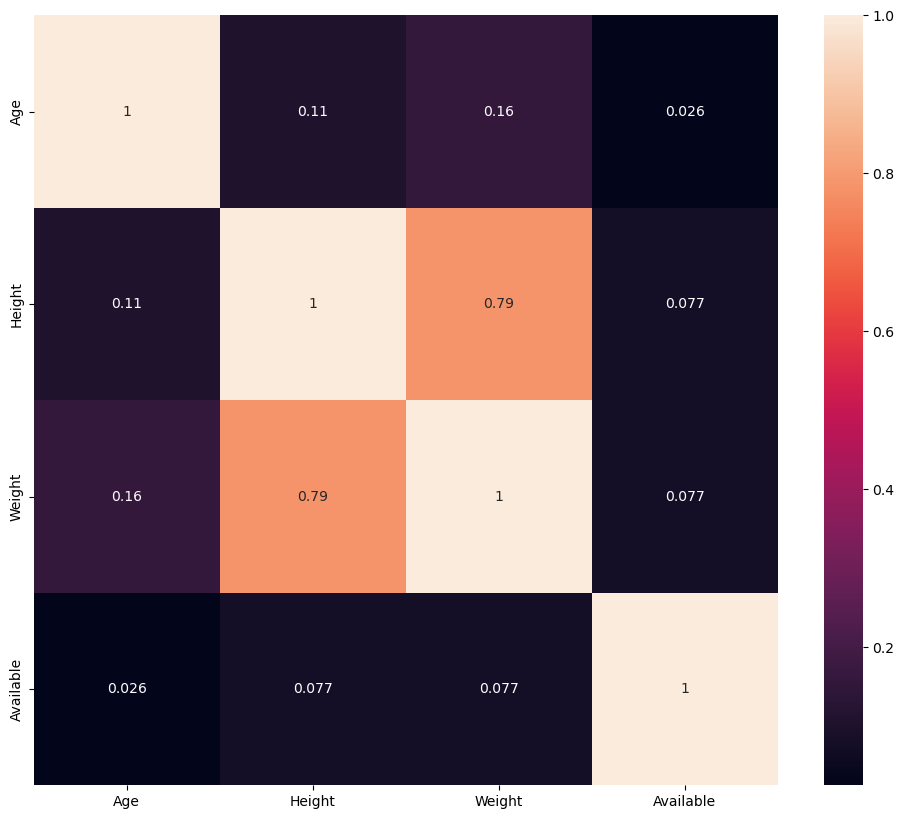

In [53]:
plt.figure(figsize=(12,10))
sns.heatmap(data=ch_corr,annot = True)
plt.show()

По данной карте можно увидеть зависимость только от роста к весу и наоборот. Очень маленькая зависимость от телосложения или возраста к наличию медалей.

8. Итог

Данные были нормализованы и приведены к данным, для правильного анализа. По произведенному анализу можно увидеть, то что, спортсменов мужчин больше, чем женщин, зависимость роста от веса, три самых популярных видов спорта, в каком процентном соотношении относятся медали, какой преимущественно рост, вес и возраст спортсменов. 